In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

warnings.filterwarnings('ignore')
output_notebook()

def h_blend_optimized(params, details=False, output_name='ensemble_sub.csv'):
    """
    Optimized rank-based blender.
    details: if True, shows extra diagnostics (KDE, summary stats).
    """
    # 1. Load and Merge Data
    path = params['path']
    id_col, target_col = params['id_target']
    
    dfs = []
    subm_names = [s['name'] for s in params['subm']]
    for name in subm_names:
        df_temp = pd.read_csv(f"{path}{name}.csv")[[id_col, target_col]]
        dfs.append(df_temp.rename(columns={target_col: name}).set_index(id_col))
    
    df_subms = pd.concat(dfs, axis=1)
    
    # 2. Weighted Rank Blending Logic
    def get_blend(df, direction):
        vals = df[subm_names].values
        main_w = np.array([s['weight'] for s in params['subm']])
        pos_w = np.array(params['subwts'])
        
        # Sort indices row-wise
        ranks = np.argsort(-vals if direction == 'desc' else vals, axis=1)
        
        blended = np.zeros(vals.shape[0])
        for i in range(len(subm_names)):
            col_idx = ranks[:, i]
            row_idx = np.arange(len(vals))
            # Calculate: Value * (Base Weight of that model + Weight of that rank position)
            blended += vals[row_idx, col_idx] * (main_w[col_idx] + pos_w[i])
        return blended

    desc_blend = get_blend(df_subms, 'desc')
    asc_blend = get_blend(df_subms, 'asc')
    
    # Apply global asc/desc weights
    w_asc, w_desc = params['type_sort'][1], params['type_sort'][2]
    final_pred = (w_desc * desc_blend) + (w_asc * asc_blend)
    
    df_final = df_subms.copy()
    df_final[target_col] = final_pred
    
    # 3. Output
    df_out = df_final[[target_col]].reset_index()
    df_out.to_csv(output_name, index=False)
    
    # 4. Diagnostics (The 'details' logic)
    if details:
        print("Ensemble Summary Statistics:")
        print(df_out[target_col].describe())
        
        plt.figure(figsize=(12, 5))
        for name in subm_names:
            sns.kdeplot(df_subms[name], label=f"Model: {name}", alpha=0.4)
        sns.kdeplot(final_pred, label='Final Ensemble', linewidth=3, color='black', linestyle='--')
        plt.title("Comparison of Model Distributions vs. Final Ensemble")
        plt.legend()
        plt.show()

    return df_out

Loading BokehJS ...

Ensemble Summary Statistics:
count    1.447107e+06
mean    -8.857333e-01
std      4.066719e+00
min     -7.392301e+01
25%     -1.369242e-01
50%     -2.274622e-03
75%      3.348486e-04
max      1.234381e+01
Name: prediction, dtype: float64


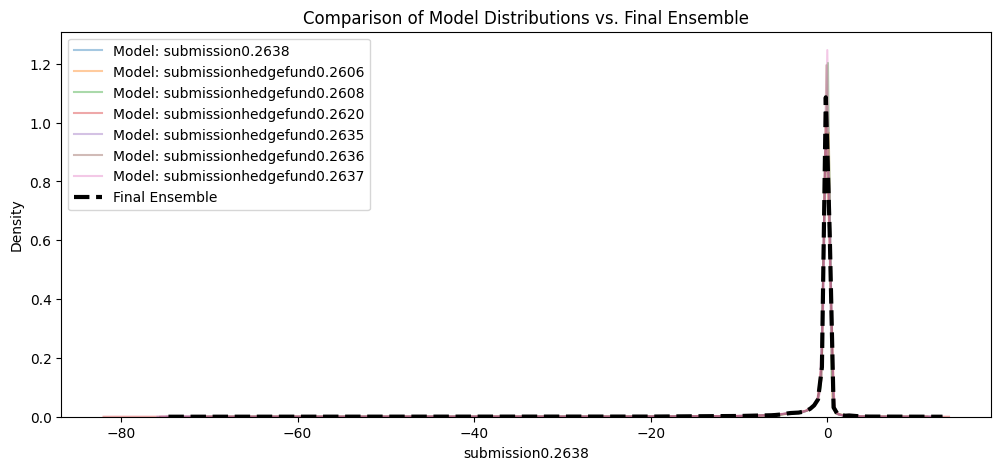

CPU times: user 1min 19s, sys: 2.1 s, total: 1min 21s
Wall time: 1min 20s


In [2]:
%%time

params = {
      # Ensure path matches standard Kaggle format or keep your custom path if verified
      'path'     : f'/kaggle/input/datasets/kami1976/hedge-fund-time-series4/',            
      'id_target': ['id',"prediction",],          
      'type_sort': ['asc/desc',0.30,0.70 ],
      'subwts'   : [w/100 for w in [ +12, +6, +3, -1, -4, -6, -10 ]],
      'subm'     : [
          # Added files for model regularization (weights sum to exactly 1.0)
          {'name': f'submission0.2638', 'weight':+0.65, 'color':'orange'},
          {'name': f'submissionhedgefund0.2606', 'weight':+0.01, 'color':'green'},
          {'name': f'submissionhedgefund0.2608', 'weight':+0.02, 'color':'crimson'},
          {'name': f'submissionhedgefund0.2620', 'weight':+0.04, 'color':'darkgray'},
          {'name': f'submissionhedgefund0.2635', 'weight':+0.06, 'color':'silver'},
          {'name': f'submissionhedgefund0.2636', 'weight':+0.08, 'color':'cyan'},
          {'name': f'submissionhedgefund0.2637', 'weight':+0.14, 'color':'crimson'},]
}
df = h_blend_optimized(params, details=True)

# Cleanup
for file in ['cross.csv', 'tida_desc.csv']: 
    if os.path.exists(file): 
        os.remove(file)


In [3]:
df.to_csv('submission.csv',index=False)
df

,id,prediction
0,10BAVIDU__07YQ9WA4__DPPUO5X2__1__4175,-0.030902
1,10BAVIDU__07YQ9WA4__DPPUO5X2__1__4176,-0.028501
2,10BAVIDU__07YQ9WA4__DPPUO5X2__1__4177,-0.018331
3,10BAVIDU__07YQ9WA4__DPPUO5X2__1__4178,-0.004094
4,10BAVIDU__07YQ9WA4__DPPUO5X2__1__4179,-0.020229
...,...,...
1447102,X9BZ68VQ__YKU5BVSL__V8BKY1IV__25__4372,2.725101
1447103,X9BZ68VQ__YKU5BVSL__V8BKY1IV__25__4373,2.780301
1447104,X9BZ68VQ__YKU5BVSL__V8BKY1IV__25__4374,2.770952
1447105,X9BZ68VQ__YKU5BVSL__V8BKY1IV__25__4375,2.797938
